In [ ]:
from langchain_groq import ChatGroq
import os
os.getenv('GROQ_API_KEY')
os.environ['GROQ_API_KEY'] = ''

llm = ChatGroq(model="llama-3.1-8b-instant",api_key = os.getenv('GROQ_API_KEY'))

/Users/roraghav/Agentic-AI- course/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
#Step 1: Load Doc from Datasource
from langchain_community.document_loaders import PyPDFLoader
loader = PyPDFLoader("Transformers.pdf")
docs = loader.load()

#Step 2: Split Doc into chunks
from langchain_text_splitters import CharacterTextSplitter
text_splitter = CharacterTextSplitter(chunk_size=100,chunk_overlap=20)
docs = text_splitter.split_documents(docs)

#Step 3: Convert chunks to embeddings
from langchain_community.embeddings import HuggingFaceBgeEmbeddings
embedding_model = HuggingFaceBgeEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

#Step 4: Store in Vector DB
from langchain_community.vectorstores import FAISS
vector_store = FAISS.from_documents(docs,embedding_model)

#Step 5: Test similarity search
vector_store.similarity_search_with_score("transformer")

#Step 5 : Create Retriever object
retriever_obj = vector_store.as_retriever()

#Step 6: Create llm object
os.environ['GROQ_API_KEY']=""
llm=ChatGroq(
    model="llama-3.1-8b-instant",
    api_key=os.getenv('GROQ_API_KEY')
)

#Step 7: Test
llm.invoke("Hello, Im Roshan, Student")

/var/folders/ty/9g1jb5w55jv91yjqg7kz79mw0000gn/T/ipykernel_67109/1309918925.py:13: LangChainDeprecationWarning: The class `HuggingFaceBgeEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embedding_model = HuggingFaceBgeEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 12235.91it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[(Document(id='e9d26a89-7aef-43ab-bc13-f594ddafaf23', metadata={'producer': 'PyPDF', 'creator': 'Google', 'creationdate': '', 'title': 'Transformers tutorial', 'source': 'Transformers.pdf', 'total_pages': 187, 'page': 116, 'page_label': '117'}, page_content='Major Applications \nof Transformers'),
  np.float32(0.5493238)),
 (Document(id='8ec5f2bb-ee00-486e-8620-d986c86c4f57', metadata={'producer': 'PyPDF', 'creator': 'Google', 'creationdate': '', 'title': 'Transformers tutorial', 'source': 'Transformers.pdf', 'total_pages': 187, 'page': 86, 'page_label': '87'}, page_content='Transformers and LLMs: An Introduction\n87'),
  np.float32(0.68102753)),
 (Document(id='44c29382-86df-4f76-81f1-ed5a1cf22efd', metadata={'producer': 'PyPDF', 'creator': 'Google', 'creationdate': '', 'title': 'Transformers tutorial', 'source': 'Transformers.pdf', 'total_pages': 187, 'page': 96, 'page_label': '97'}, page_content='97Self-Attention\nhttps://jalammar.github.io/illustrated-transformer/'),
  np.float32(0.

In [3]:
llm.invoke("What is my name?")

AIMessage(content="I don't have any information about your name. I'm a large language model, I don't have the ability to know or remember personal information about individual users. Each time you interact with me, it's a new conversation and I don't retain any information from previous conversations. If you'd like to share your name with me, I'd be happy to chat with you!", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 77, 'prompt_tokens': 40, 'total_tokens': 117, 'completion_time': 0.121683319, 'completion_tokens_details': None, 'prompt_time': 0.003206056, 'prompt_tokens_details': None, 'queue_time': 0.052656503, 'total_time': 0.124889375}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019db897-e626-7240-8276-f0ad2be6a3e3-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 40, 'output_tokens

In [4]:
store={} # empty dict

store['p101']=['pA',1000,'Vendor-1']
store['p102']=['pB',1000,'Vendor-2']
store['p103']=['pC',1000,'Vendor-3']
store['p104']=['pD',1000,'Vendor-4']

store

{'p101': ['pA', 1000, 'Vendor-1'],
 'p102': ['pB', 1000, 'Vendor-2'],
 'p103': ['pC', 1000, 'Vendor-3'],
 'p104': ['pD', 1000, 'Vendor-4']}

'''
User_Q: Hello Im Theeba
AI: Hello Theeba. How can I assist You
User_Q: renewal of website domain
AI: Enter your domain
User_Q:...
Ai: Are you there?
...
------------------------------// Session is expired session-1
USer_Q: THis is my domain
Ai: May  know who are?   --// new_session- session-2



|-------------------------------|------------------------------|
|  Session_ID                   | Chat( Human + AI)
|-------------------------------|-------------------------------|
|                               |  User:..
| Session-1                    |   Ai:...
|
|-------------------------------|------------------------------|

|-------------------------------|-------------------------------|
|                               |  User:..
| Session-2                    |   Ai:...
|
|-------------------------------|------------------------------|

'''

# Chat History
#------------
# ChatMessageHistory ----- instance -> store (User + AI) dict
# BaseChatMessageHistory  ---> Base Class
# RunnableWithMessageHistory --> wrapper class

In [5]:
from langchain_community.chat_message_histories import ChatMessageHistory
from langchain_core.chat_history import BaseChatMessageHistory
from langchain_core.runnables.history import RunnableWithMessageHistory


In [6]:
store = {}

def get_session_history(session_id:str)->BaseChatMessageHistory:
    if session_id not in store:
        store[session_id]=ChatMessageHistory()
    return store[session_id]

In [7]:
obj = RunnableWithMessageHistory(llm,get_session_history)

In [8]:
my_config = {"configurable":{"session_id":"chat1"}}

In [12]:
obj.invoke("Hello I am Roshan, student of AI agent class",config=my_config)

AIMessage(content="Nice to meet you, Roshan. Welcome to the AI agent class. I'm here to help you with any questions or topics related to AI and machine learning. What would you like to discuss or explore today? Are you working on a project, or do you have a specific topic in mind that you'd like to learn more about?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 70, 'prompt_tokens': 47, 'total_tokens': 117, 'completion_time': 0.174690215, 'completion_tokens_details': None, 'prompt_time': 0.783662728, 'prompt_tokens_details': None, 'queue_time': 0.060167204, 'total_time': 0.958352943}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019db8a7-5e42-7ea1-82d8-2b4762ae899c-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 47, 'output_tokens': 70, 'total_tokens': 117})

In [14]:
response = obj.invoke("What is my Name?",config=my_config)
print(response.content)

Your name is Roshan. You mentioned it at the beginning of our conversation.


In [15]:
my_config = {"configurable":{"session_id":"chat2"}}
response = obj.invoke("What is my Name?",config=my_config)
print(response.content)

I don't have information about your name as our conversation has just started. I'm a large language model, I don't have personal knowledge about individual users unless they explicitly share that information. If you'd like to share your name with me, I'd be happy to chat with you.


In [16]:
my_config = {"configurable":{"session_id":"chat1"}}
response = obj.invoke("What am I",config=my_config)
print(response.content)

You are a student of the AI agent class.


# Load doc-> split chunks -> create embedding -> store in Vector DB -> create retrievalQA object
#                                                -> create RAG chain - retrieval Obj| llm| prompt( store chat history)

Strict Rag - answer only from doc (Made using prompt)

In [ ]:
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph
from langchain_core.tools import tool
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import CharacterTextSplitter
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_classic.chains import RetrievalQA
from langchain_core.prompts import ChatPromptTemplate
from langchain_community.chat_message_histories import ChatMessageHistory
from langchain_core.chat_history import BaseChatMessageHistory
from langchain_core.runnables.history import RunnableWithMessageHistory
from langchain_classic.chains.combine_documents import create_stuff_documents_chain
from langchain_classic.chains import create_retrieval_chain
from langchain_core.messages import AIMessage
import os

#Step 1: Load Doc from Datasource

loader_obj=PyPDFLoader("Transformers.pdf")
docs=loader_obj.load()


#Step 2: Split Doc into chunks
text_splitter=CharacterTextSplitter(chunk_size=100,chunk_overlap=20)
chunks=text_splitter.split_documents(docs)

#Step 3: Convert chunks to embeddings

embedding_model=HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

#Step 4: Store in Vector DB

vector_store=FAISS.from_documents(chunks,embedding_model)

#Step 5 : Create Retriever object
retriever_obj = vector_store.as_retriever()

#Step 6: Create llm object

os.environ['GROQ_API_KEY']=""

# Initialize llm obj

llm=ChatGroq(
    model="llama-3.1-8b-instant",
    api_key=os.getenv('GROQ_API_KEY')
)
'''
# Step 6: Create a retrivalQA obj

qaChain=RetrievalQA.from_chain_type(
    llm=llm,
    retriever=vector_store.as_retriever()
)
'''
# Step 7: Create Prompt
# Strict RAG- answer only doc - prompt- answer ONLY from doc.
prompt= ChatPromptTemplate.from_template(
    """
You are a helpul Ai Assistant.
Use the following context and previous chat history to answer the user's question.
If you don't know the answer, just say that you don't know.
Don't try to make up an answer.
Chat History:
{history}

Context:
{context}

Question:
{input}
    """
)

# Create RAG Chain

# Create_stuff_documents_chain() - llm+ prompt--> chain
# create_retriever_chain() - retriever + chain

doc_chain= create_stuff_documents_chain(llm, prompt)

rag_chain= create_retrieval_chain( retriever_obj, doc_chain)


# Convert output to AIMessage
def convert_to_ai_message(output):
  return AIMessage(content=output["answer"])

final_chain = rag_chain | convert_to_ai_message


# Store Chat History

store={}

def get_session_history(session_id:str)-> BaseChatMessageHistory:
    if session_id not in store:
        store[session_id]=ChatMessageHistory()
    return store[session_id]

# Wrap chain with history

rag_with_history= RunnableWithMessageHistory(
    final_chain,
    get_session_history,
    input_messages_key="input",
    history_messages_key="history"
    )


# Chat loop

session_id= "session-1"

print("RAG ChatBot Started\n")

while True:
  query = input("You : ")

  if query.lower() == "exit":
    print("Chat Ended")
    break
  response = rag_with_history.invoke(
      {"input":query},
      config={"configurable":{"session_id":session_id}}
  )
  print(f"AI : {response.content}\n")


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7786.41it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


RAG ChatBot Started

AI : Based on our previous chat history and context, I can try to help you understand what self-attention is.

Self-attention is a mechanism used in transformer models, particularly in the multi-head self-attention layer. In this layer, the output of the previous layer is taken as input, and it is broken down into three components: Query (Q), Key (K), and Value (V).

The self-attention mechanism calculates the weighted sum of the Value (V) components based on the similarity between the Query (Q) and Key (K) components. This is done by computing the dot product of Q and K, followed by a softmax function to normalize the weights.

In simpler terms, self-attention allows the model to focus on different parts of the input sequence (e.g., words or tokens) and assign more importance to those parts that are relevant to the task at hand.

Let me know if you'd like me to elaborate or if you have any further questions!

Chat Ended


In [ ]:
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph,END
from langchain_core.tools import tool
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import CharacterTextSplitter
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_classic.chains import RetrievalQA
from langchain_core.prompts import ChatPromptTemplate
from langchain_community.chat_message_histories import ChatMessageHistory
from langchain_core.chat_history import BaseChatMessageHistory
from langchain_core.runnables.history import RunnableWithMessageHistory
from langchain_classic.chains.combine_documents import create_stuff_documents_chain
from langchain_classic.chains import create_retrieval_chain
from langchain_core.messages import AIMessage,HumanMessage
from  typing import TypedDict
import os


# from langchain.chains.combine_documents import create_stuff_documents_chain  - newer version of langchain
# from langchain.chains import create_retrieval_chain


# Load doc-> split chunks -> create embedding -> store in Vector DB -> create retrievalQA object
#                                                -> create RAG chain - retrieval Obj| llm| prompt( store chat history)



#Step 1: Load Doc from Datasource

loader_obj=PyPDFLoader("Transformers.pdf")
docs=loader_obj.load()


#Step 2: Split Doc into chunks
text_splitter=CharacterTextSplitter(chunk_size=100,chunk_overlap=20)
chunks=text_splitter.split_documents(docs)

#Step 3: Convert chunks to embeddings

embedding_model=HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

#Step 4: Store in Vector DB

vector_store=FAISS.from_documents(chunks,embedding_model)

#Step 5 : Create Retriever object
retriever_obj = vector_store.as_retriever()

#Step 6: Create llm object

os.environ['GROQ_API_KEY']=""

# Initialize llm obj

llm=ChatGroq(
    model="llama-3.1-8b-instant",
    api_key=os.getenv('GROQ_API_KEY')
)
'''
# Step 6: Create a retrivalQA obj

qaChain=RetrievalQA.from_chain_type(
    llm=llm,
    retriever=vector_store.as_retriever()
)
'''
# Step 7: Create Prompt
# Strict RAG- answer only doc - prompt- answer ONLY from doc.
prompt= ChatPromptTemplate.from_template(
    """
You are a helpul Ai Assistant.
Use the following context and previous chat history to answer the user's question.
If you don't know the answer, just say that you don't know.
Don't try to make up an answer.
Chat History:
{history}

Context:
{context}

Question:
{input}
    """
)


# Store Chat History

store={}

def get_session_history(session_id:str)-> BaseChatMessageHistory:
    if session_id not in store:
        store[session_id]=ChatMessageHistory()
    return store[session_id]


# load doc-> split chunks-> embedding generation -> store db  - same
# langgraph
#       - generate Node - context + history + prompt --> response
#       - retriever Node - context from db- shared mem


# Build Langgraph

# State Schema

class State(TypedDict):
  question: str
  session_id: str
  context: str
  answer: str


# Node1 : Retriever Node

def retriever_node(state: State):
  question= state["question"]
  retrieved_doc = retriever_obj.invoke(question)

  context= "\n\n".join(
      [  doc.page_content for doc in retrieved_doc]
  )

  return {"context":context}


# Generate Node
def generate(state:State):
  question = state["question"]
  context = state["context"]
  session_id = state["session_id"]

  history= get_session_history(session_id)

  history_text= "\n".join(
      [f"{message.type}:{message.content}" for message in history.messages]
  )

  chain = prompt | llm

  response = chain.invoke(
      {
          "history" : history_text,
          "context" : context,
          "input" : question
      },
      config={"configurable":{"session_id":session_id}}
  )

  final_answer = response.content

  # Save this to History
  history.add_message(HumanMessage(content=question))
  history.add_message(AIMessage(content=final_answer))

  return {"answer":final_answer}


builder = StateGraph(State)
builder.add_node("retrieval",retriever_node)
builder.add_node("generate",generate)

builder.set_entry_point("retrieval")

builder.add_edge("retrieval","generate")
builder.add_edge("generate",END)

app= builder.compile()

# Chat loop

session_id= "agentic-rag-session"

print("\nAgentic RAG ChatBot Started\n")

while True:
  query = input("You : ")

  if query.lower() == "exit":
    print("Chat Ended")
    break
  response = app.invoke({
      "question":query,
      "session_id":session_id
  }
  )
  print(f"AI: {response["answer"]}\n")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7195.19it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Agentic RAG ChatBot Started

AI: Based on our previous chat history, I recall that we've discussed the Transformer layer and multi-head self-attention.

Self-attention is a mechanism in the Transformer model that allows the model to weigh the importance of different input elements relative to each other. It's a way for the model to focus on the most relevant parts of the input when making predictions.

In simpler terms, self-attention helps the model understand the relationships between different elements in the input, and it allows it to attend to the most important ones when generating the output.

We've also seen an example of multi-head self-attention, which is a variation of self-attention that uses multiple attention heads to capture different aspects of the input.

AI: Based on our previous chat history and the given context, I'll provide 4 bullet points related to the topic of self-attention and its relevance to the given context:

* **Self-Attention in Few-Shot Prompting**: S

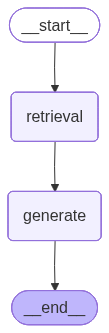

In [30]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

FROM HERE
db-> question, answer, created_on
doc-> attention.pdf

vector db--> doc-> embeddings -> FAISS
          --> db (question,answer) -> embedding -> FAISS - similarity_search

llm- refer - Vector db - relevent chunk regd doc_chunks
    history - dict
    history- db

In [32]:
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph,END
from langchain_core.tools import tool
from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import CharacterTextSplitter
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_classic.chains import RetrievalQA
from langchain_core.prompts import PromptTemplate
from langchain_community.chat_message_histories import ChatMessageHistory
from langchain_core.chat_history import BaseChatMessageHistory
from langchain_core.runnables.history import RunnableWithMessageHistory
from langchain_classic.chains.combine_documents import create_stuff_documents_chain
from langchain_classic.chains import create_retrieval_chain
from langchain_core.messages import AIMessage,HumanMessage

import sqlite3
from datetime import datetime
from langchain_core.documents import Document

In [ ]:

# Step 1:  Sqlite3 DB _ LTM chat History

conn = sqlite3.connect('long_term_memory.db')
cursor = conn.cursor()

cursor.execute('''
    CREATE TABLE IF NOT EXISTS chat_history (
        id INTEGER PRIMARY KEY,
        user_question TEXT,
        ai_answer TEXT,
        created_at TEXT
    )
''')

conn.commit()


# Step 2:  Load Documents

loader= TextLoader("my_docs.txt")
documents= loader.load()

# Step 3: Split Documents

text_splitter =CharacterTextSplitter(chunk_size=500, chunk_overlap=50)
doc_chunks = text_splitter.split_documents(documents)

# Step 4: Embeddings

embedding_model = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

# Step 5:  Vector Store ( Document Vector store)
document_vectorstore = FAISS.from_documents(doc_chunks, embedding_model)

# Step 6: LTM Vector Store
memory_docs= [Document(page_content="Initial memory placeholder")]
memory_vectorstore = FAISS.from_documents(memory_docs, embedding_model)

# Step 7: Retriever

document_retriever = document_vectorstore.as_retriever(search_kwargs={"k": 2})

# Step 8: LLM Object


os.environ['GROQ_API_KEY']=""

# Initialize llm obj

llm=ChatGroq(
    model="llama-3.1-8b-instant",
    api_key=os.getenv('GROQ_API_KEY')
)


# Step 9: Prompt


prompt =PromptTemplate(
    input_variables=["context", "question", "memory"],
    template="""
You are a strict QA Assistant
use ONLY document context and previous memory.

Previos memory:
{memory}

Document context:
{context}

Question:
{question}

If answer is not present in context and memory, replay exactly
"I don't know ! document doesnot contain this information"

Answer:
    """
)
# Step 10: QA Chain

rag_chain = RetrievalQA.from_chain_type(
    llm=llm,
    chain_type="stuff",
    retriever=document_retriever,
    chain_type_kwargs={"prompt": prompt})

# Step 11: Save To LTM

def save_chat_memory(user_question, ai_answer):
  memory_vectorstore.add_documents([Document(page_content=f"{user_question}\n{ai_answer}")]) # sto
  cursor.execute("""insert into chat_history(user_question,ai_answer,created_at)
    values(?,?,?)""",(user_question,ai_answer,datetime.now().isoformat()))
  conn.commit()

# Step 12: Retrive LTM
def retrieve_memory(query, k=2):
  memory_results =memory_vectorstore.similarity_search(query,k=k)
  return "\n".join([ doc.page_content for doc in memory_results])

# Step 13: Rag - Ask questions

def ask_rag(question):
  # Retrieve previous memory
  memory = retrieve_memory(question)

  # Retrieve doc context
  relevant_docs = document_retriever.invoke(question)
  context ="\n".join([doc.page_content for doc in relevant_docs])

  # final prompt
  final_prompt = prompt.format(context=context, question=question, memory=memory)
  #print(final_prompt)
  # call LLM
  response = llm.invoke(final_prompt)
  answer= response.content

  # save to LTM
  save_chat_memory(question,answer)
  return answer

# Step 14:
# Chat - Menu- Loop

while(True):
  user_question = input("\n Ask Question :")

  if( user_question.lower() == "exit"):
    break
  response = ask_rag(user_question)
  print(f"\n Answer : {response}")



Created a chunk of size 868, which is longer than the specified 500
Created a chunk of size 858, which is longer than the specified 500
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 13792.21it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



 Answer : LangChain is an open-source orchestration framework designed to simplify the creation of applications powered by Large Language Models (LLMs). It acts as a "bridge" or "glue," connecting raw AI models to external data, tools, and workflows to build context-aware, reasoning-capable systems.

 Answer : Agent's description in the document mentions that agents use an LLM as a "reasoning engine" to decide which actions to take and which tools to call. 

Therefore, based on the given information, a 'tool' is an external entity or system that an agent interacts with or calls to achieve a specific goal.

 Answer : I don't have information about evaporation in my memory or within the document context. 

"I don't know ! document does not contain this information"

 Answer : Based on the document context and previous memory, here are 2 bullet points about the concept of a 'tool':

• A 'tool' is an external entity or system that an agent interacts with or calls to achieve a specific goa

In [37]:
conn = sqlite3.connect('long_term_memory.db')
cursor = conn.cursor()

sth=cursor.execute("select * from chat_history")
list(sth)

[(1,
  'What is chain?',
  "I don't know ! document does not contain this information.",
  '2026-04-23T15:18:23.493493'),
 (2,
  'What is lanchain',
  'LangChain is an open-source orchestration framework designed to simplify the creation of applications powered by Large Language Models (LLMs).',
  '2026-04-23T15:18:35.723505'),
 (3,
  'Answer in 3 bullet point',
  'Based on the given document context and memory, the answer to the question is:\n\n* Retrieval-Augmented Generation (RAG) is a technique that fetches relevant data from external sources and provides it as context to the LLM to reduce hallucinations and provide up-to-date answers.\n* Fine-tuning involves retraining a model on specific data, whereas RAG provides the data to the model at "runtime" without expensive retraining.\n* Chains are sequences of automated actions where the output of one step becomes the input for the next.',
  '2026-04-23T15:18:47.706110'),
 (4,
  'what is langchain?',
  'LangChain is an open-source orch

In [ ]:
# Oracle 23ai db

# Step 1- Connect to Oracle23ai db
import oracledb

conn= oracledb.connect(user="",password="",dsn="")
cursor =conn.cursor()

cursor.execute("""
create table if not exists chat_history{
  id INTEGER PRIMARY KEY,
  content CLOB,
  embedding VECTOT(384),
  created_at TIMESTAMP,

""")

conn.commit()


# Step 2:  Load Documents
loader= TextLoader("my_docs.txt")
documents= loader.load()

# Step 3: Split Documents

text_splitter =CharacterTextSplitter(chunk_size=500, chunk_overlap=50)
doc_chunks = text_splitter.split_documents(documents)

# Step 4: Embeddings

embedding_model = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

# Step 5:  Vector Store ( Document Vector store)
document_vectorstore = FAISS.from_documents(doc_chunks, embedding_model)

# Step 6: LTM  Memory vector store
def insert_documents(text):
  embedding = embedding_model.embed_query(text)
  cursor.execute("""
    insert into chat_history(content,embedding)
    values(:1,:2)
    """,(text,embedding))

for doc in doc_chunks:
  insert_documents(doc.page_content)

conn.commit()


# Step 7:  Retrieve Vector store - oracle - similarity search inside db

def retrieve_context(query,k=2):
  query_embedding= embedding_model.embed_query(query)

  cursor.execute(f'''
  SELECT content FROM chat_history
  ORDER BY VECTOR_DISTANCE(embedding,:1)
  FETCH FIRST {k} ROWS ONLY
  ''',[query_embedding])

  results = cursor.fetchall()
  return "\n".join(result[0] for result in results)

# Step 8: LLM Object


os.environ['GROQ_API_KEY']=""

# Initialize llm obj

llm=ChatGroq(
    model="llama-3.1-8b-instant",
    api_key=os.getenv('GROQ_API_KEY')
)


# Step 9: Prompt

prompt =PromptTemplate(
    input_variables=["context", "question", "memory"],
    template="""
You are a strict QA Assistant
use ONLY document context and previous memory.

Previos memory:
{memory}

Document context:
{context}

Question:
{question}

If answer is not present in context ans memory, replay exactly
"I don't know ! document doesnot contain this information"

Answer:
    """
)

# Step 10:  Save memory
def save_memory(question,answer)
  memory_text= f"Q:{question}\n Ans:{answer}"
  embedding = embedding_model.embed_query(memory_text)

  cursor.execute("""
  insert into chat_history(content,embedding)
  values(:1,:2)
  """,(memory_text,embedding))

  conn.commit()


# Step 11: Retrieve memory

def retrieve_memory(query,k=2):
  query_embedding= embedding_model.embed_query(query)

  cursor.execute(f'''
  SELECT content FROM chat_history
  ORDER BY VECTOR_DISTANCE(embedding,:1)
  FETCH FIRST {k} ROWS ONLY
  ''',[query_embedding])

  results = cursor.fetchall()
  return "\n".join(result[0] for result in results)

# Step 12: Ask

def ask_rag(question):

  # Retrieve memory
  memory = retrieve_memory(question)

  # Retrieve doc memory
  context= retrieve_context(question)

  # final prompt

  final_prompt = prompt.format(
      memory=memory,
      context= context,
      question=question
  )


  response = llm.invoke(final_prompt)
  answer= response.content

  # Save memory
  save_memory(question,answer)
  return answer

# Step 13: Menu- Loop


while(True):
  user_question = input("\n Ask Question :")

  if( user_question.lower() == "exit"):
    break
  response = ask_rag(user_question)
  print(f"\n Answer : {response}")


#Memory- Agentic Ai

# 1. Short Term memory - CoT, tool output - RAG - session based - Context + Prompt + chat history
# 2. Long Term memory - db/ file - Vector db- sematic search - GoT
# 3. Episodic memory - log / timeline

User Input
|
[Short Term Memory] - state
|
Retrieve doc knowledge  --[long term memory]
|
Check Past experience - [ Episodic memory]
|
Agent reasoning
|
Action
|
Store response -- Episodic + Long Term memory


In [38]:
memory=[]
def chat(user_input):
  memory.append(HumanMessage(content=user_input))
  response = llm.invoke(memory)
  memory.append(AIMessage(content=response.content))
  return response.content

#test

print(chat("Hello this is Theeba"))
print(chat("what is my name?"))

Hello Theeba, it's nice to meet you. Is there something I can help you with or would you like to chat?
Your name is Theeba.


In [40]:
from langchain_community.vectorstores import FAISS
from langchain_community.embeddings import HuggingFaceEmbeddings

# Create Embedding Obj + embedding in vectore store

embeddings=  HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

text=["Theeba like Python", "Theeba now working in ai"]

vector_store= FAISS.from_texts(text,embeddings)

# Retrieve
query="What is Theeba doing?"
doc= vector_store.similarity_search(query)

print(doc[0].page_content)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 9270.87it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Theeba now working in ai
